Testcase for the MTPCL implementation

In [1]:
# imports
import numpy as np
import gym_electric_motor as gem
from gym_electric_motor.physical_systems import ConstantSpeedLoad
from gym_electric_motor.reference_generators import  ConstReferenceGenerator
from gym_electric_motor.physical_system_wrappers import DeadTimeProcessor
from gym_electric_motor.physical_systems.solvers import EulerSolver

import gem_controllers as gc

In [2]:
# define the environment

motor_env_id = "Cont-TC-EESM-v0"
tau = 1e-4    # The duration of each sampling step



T_generator = ConstReferenceGenerator('torque', 0.5)

motor_parameter = {
        'p': 2,
        'l_d': 3.78e-3,
        'l_q': 1.21e-3,
        'l_m': 40e-3, 
        'l_e': 870e-3,
        'j_rotor': 0.3883,
        'r_s': 123e-3,
        'r_e': 15.6,
        'k': 0.057,
    }

limit_values = dict(
    omega = 7e+3*np.pi/30,
    i = 31.25,
    u = 200,
    #u_e = 200,
    i_e = 6.25,
    torque = 20,
    )

nominal_values=dict(
    omega = 2e+3*np.pi/30,  # angular velocity in rad/s
    i = 25,                   # motor current in amps
    u = 200,                  # nominal voltage in volts
    #u_e = 200,
    i_e = 5,
    torque = 15,
    )

eesm_init = {
    'states': {
        'i_sd' : 0.,
        'i_sq' : 0.,
        'i_e' : 0.,
        'epsilon' : 0.,
        }
    }

load = ConstantSpeedLoad(omega_fixed=0.15*limit_values['omega'],)

physical_system_wrappers = [
    
    DeadTimeProcessor(steps=1) # Only use DeadTimeWrapper after you have implemented a last action concatinator for the state
]


env = gem.make(  
    motor_env_id,
    # visualize the results
    # parameterize the PMSM and update limitations
    motor=dict(
        motor_parameter=motor_parameter,
        limit_values=limit_values,
        nominal_values=nominal_values,
        motor_initializer=eesm_init,
    ),
    # define the random initialisation for load and motor
    load=load,
    tau=tau,
    ode_solver=EulerSolver(),
    physical_system_wrappers=physical_system_wrappers, 
    supply=dict(u_nominal=200),
    
    )


# Initialize the controller
c = gc.GemController.make(
        env,
        motor_env_id,
        a=8,
        block_diagram=False,
        current_safety_margin=0.15,
        save_block_diagram_as=(),
    )



(obs,ref), _ = env.reset(seed = 1)
c.reset()

# Take trained agent and loop over environment
i_sd = []
i_sq = []
omegas = []
i_f = []
torque = []
torque_ref = []
action_stored = []
rewards_stored = []
# obs = ["i_sd", "i_sq", "omega", "i_e", "cos(epsilon)", "sin(epsilon)"], Tref, 3 actions

niveau0 = 0
niveau1 = -15/limit_values['torque'] 
niveau2 = 15/limit_values['torque'] 



i_sd_idx = env.get_wrapper_attr('physical_system').state_positions['i_sd']
i_sq_idx = env.get_wrapper_attr('physical_system').state_positions['i_sq']
omega_idx = env.get_wrapper_attr('physical_system').state_positions['omega']
i_f_idx = env.get_wrapper_attr('physical_system').state_positions['i_e']
torque_idx = env.get_wrapper_attr('physical_system').state_positions['torque']

SLSQP iters — eq mean=14.7 max=37; fbk1 mean=2.8; fbk2 mean=2.8


In [3]:
def single_value_from_LUT(Tref_Nm: float):
    ops = c._controller._operation_point_selection
    sgn = 1.0 if Tref_Nm >= 0 else -1.0
    T_abs = min(abs(Tref_Nm), float(ops.t_max))
    return sgn * float(ops.i_q_opt(T_abs))   # the torque-producing current


In [4]:
for i in range(65000):

    

    if i <= 2500:
        env.env.unwrapped.reference_generator._reference_value = niveau0        
    elif i <= 62500:
        env.env.unwrapped.reference_generator._reference_value = niveau1 + (niveau2 - niveau1) * (i - 2500) / 60000
    else:
        env.env.unwrapped.reference_generator._reference_value = niveau0
    ref_x = env.env.unwrapped.reference_generator._reference_value

    ref_vec = np.array([float(ref_x)], dtype=float)
    action = c.control(obs,ref_x)

    (obs, ref), rewards, terminated, truncated, info = env.step(action)
    done = terminated or truncated


    # TODO: record the current references of the look up table 

    i_sd.append(obs[i_sd_idx])
    i_sq.append(obs[i_sq_idx])
    omegas.append(obs[omega_idx])
    i_f.append(obs[i_f_idx])
    torque.append(obs[torque_idx])
    torque_ref.append(ref_x)
    action_stored.append(action)
    

    if done:
        #obs,_ = env.reset(seed = 1)
        break

In [5]:
from scipy.optimize import minimize
from scipy.interpolate import interp1d

In [6]:
# %% Copper Losses Optimization for T_ref with specific speed (robust)

from scipy.optimize import minimize
import numpy as np

# constants
p, Ld, Lq, Lm = 2, 3.78e-3, 1.21e-3, 40e-3
Rs, Re, Udc = 123e-3, 15.6, 200.0
i_s_lim, i_f_lim = 25.0, 5.0

omega_el = 0.15 * limit_values['omega'] * 2.0       # electrical speed
V_over_omega = Udc / (np.sqrt(3.0) * omega_el)      # appendix-consistent

def torque(id_, iq_, iF):
    return 1.5 * p * (Lm * iF + (Ld - Lq) * id_) * iq_

def losses_eq(x):
    id_, iq_, iF = x
    return 1.5 * Rs * (id_**2 + iq_**2) + Re * (iF**2)

def cons_eq(Tref):
    return [
        {'type': 'ineq','fun': lambda x: i_s_lim**2 - (x[0]**2 + x[1]**2)},      # |is| ≤
        {'type': 'ineq','fun': lambda x: x[2]},                                   # i_f ≥ 0
        {'type': 'ineq','fun': lambda x: i_f_lim - x[2]},                         # i_f ≤
        {'type': 'ineq','fun': lambda x: V_over_omega**2
                                 - ((Lq*x[1])**2 + (Lm*x[2] + Ld*x[0])**2)},      # |psi| ≤ V/ω
        {'type': 'eq',  'fun': lambda x: torque(x[0], x[1], x[2]) - Tref},        # Te = Tref
    ]

bounds = [(-i_s_lim, i_s_lim), (-i_s_lim, i_s_lim), (0.0, i_f_lim)]

# theoretical bound (cheap); voltage constraint is often tighter at speed
T_bound = 1.5 * p * (Lm*i_f_lim + abs(Ld - Lq)*i_s_lim) * i_s_lim

# torque sweep
torque_range = np.linspace(-limit_values['torque'], limit_values['torque'], 301)

losses_Tmin = []

for Tref in torque_range:
    if abs(Tref) > T_bound + 1e-9:
        # certain infeasibility -> go directly to soft problem
        hard_ok = False
    else:
        # equality attempt with two seeds, warm-started by sign
        s = 1.0 if Tref >= 0 else -1.0
        seeds = [np.array([0.0, s*1.0, 1.0]),
                 np.array([-0.3*i_s_lim, s*0.8*i_s_lim, 0.5*i_f_lim])]
        hard_ok, x_hard = False, None
        for x0 in seeds:
            res = minimize(losses_eq, x0, method='SLSQP',
                           bounds=bounds, constraints=cons_eq(Tref),
                           options={'maxiter': 200, 'ftol': 1e-9, 'disp': False})
            if res.success:
                hard_ok, x_hard = True, res.x
                break

    if hard_ok:
        id_opt, iq_opt, iF_opt = x_hard
        losses_Tmin.append((omega_el, Tref, id_opt, iq_opt, iF_opt, losses_eq(x_hard)))
        continue

    # ---- SOFT FALLBACK (drop equality): min |Te - Tref|, then min copper losses ----
    def obj_t_err(x): return abs(torque(x[0], x[1], x[2]) - Tref)
    cons_soft = [
        {'type': 'ineq','fun': lambda x: i_s_lim**2 - (x[0]**2 + x[1]**2)},
        {'type': 'ineq','fun': lambda x: x[2]},
        {'type': 'ineq','fun': lambda x: i_f_lim - x[2]},
        {'type': 'ineq','fun': lambda x: V_over_omega**2
                                 - ((Lq*x[1])**2 + (Lm*x[2] + Ld*x[0])**2)},
    ]
    # use a sign-aware seed
    s = 1.0 if Tref >= 0 else -1.0
    x0 = np.array([0.0, s*min(i_s_lim, abs(Tref)/(1.5*p*Lm*i_f_lim+1e-6)), min(i_f_lim, 0.5*i_f_lim)])

    res1 = minimize(obj_t_err, x0, method='SLSQP',
                    bounds=bounds, constraints=cons_soft,
                    options={'maxiter': 200, 'ftol': 1e-9, 'disp': False})
    if res1.success:
        res2 = minimize(losses_eq, res1.x, method='SLSQP',
                        bounds=bounds, constraints=cons_soft,
                        options={'maxiter': 200, 'ftol': 1e-9, 'disp': False})
        x_use = res2.x if res2.success else res1.x
        losses_Tmin.append((omega_el, Tref, x_use[0], x_use[1], x_use[2], losses_eq(x_use)))
    else:
        print(f"Optimization failed for omega_el={omega_el} and torque={Tref}")
        losses_Tmin.append((omega_el, Tref, None, None, None, None))


c:\Users\revanth achary\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


In [7]:
# %% Copper Losses Optimization for T_ref with specific speed
# Define the losses equation (to be minimized)
def losses_eq(input):
    isd, isq, i_f = input
    return (1.5 * (isd**2 + isq**2) * 123e-3) + (i_f**2 * 15.6)

# Define the constraints, 80persecond = 160 in ele
def constraints(torque_):
    return [
        {'type': 'ineq', 'fun': lambda input: 25 - np.sqrt(input[0]**2 + input[1]**2)},  # id**2 + iq**2 <= iLim**2
        {'type': 'ineq', 'fun': lambda input: 5**2 - input[2]**2},  # iF <= iLim
        {'type': 'ineq', 'fun': lambda input: (200/40)**2 - (1.21e-3 * input[1])**2 - (40e-3 * input[2] + 3.78e-3 * input[0])**2},  # voltage constraints
        # {'type': 'ineq', 'fun': lambda input: (100)**2 - 0},
        {'type': 'eq', 'fun': lambda input: ((1.5 * 2 * input[1]) * (40e-3 * input[2] + (3.78e-3 - 1.21e-3) * input[0])) - torque_}  # torque constraint
    ]

# Initial guess for the variables
initial_guess = [1, 1, 1]  # Start with non-zero initial guess to avoid division by zero in constraints
Tmax_req = min(limit_values['torque'], T_bound)
torque_range = np.linspace(-Tmax_req, Tmax_req, 301)


#torque_range = np.multiply(torque_ref,limit_values['torque'])#np.linspace(-15, 15, 300)
ele_speed = 0.15 * limit_values['omega'] * 2 # Example electrical speed in rad/s

losses_Tmin = []

# Iterate over omega_el and torque values and perform optimization
for torque_ in torque_range:
    # Define the optimization problem for the current omega_el and torque
    result = minimize(losses_eq, initial_guess, constraints=constraints(torque_), method='SLSQP')
    
    # Extract the results
    if result.success:
        isd_opt, isq_opt, iF_opt = result.x
        minimized_value = result.fun  # This is the minimized losses value
        losses_Tmin.append((ele_speed, torque_, isd_opt, isq_opt, iF_opt, minimized_value))
    else:
        print(f"Optimization failed for omega_el={ele_speed} and torque={torque_}")
        losses_Tmin.append((ele_speed, torque_, None, None, None, None))

Optimization failed for omega_el=219.91148575128548 and torque=-19.818749999999998
Optimization failed for omega_el=219.91148575128548 and torque=-19.686625
Optimization failed for omega_el=219.91148575128548 and torque=-19.554499999999997
Optimization failed for omega_el=219.91148575128548 and torque=-19.422375
Optimization failed for omega_el=219.91148575128548 and torque=-19.290249999999997
Optimization failed for omega_el=219.91148575128548 and torque=-19.158125
Optimization failed for omega_el=219.91148575128548 and torque=-19.025999999999996
Optimization failed for omega_el=219.91148575128548 and torque=-18.893874999999998
Optimization failed for omega_el=219.91148575128548 and torque=-18.76175
Optimization failed for omega_el=219.91148575128548 and torque=-18.629624999999997
Optimization failed for omega_el=219.91148575128548 and torque=-18.4975
Optimization failed for omega_el=219.91148575128548 and torque=-18.365374999999997
Optimization failed for omega_el=219.91148575128548 

In [8]:
# single-Tref feasibility check 

import numpy as np


p  = 2
Ld = 3.78e-3; Lq = 1.21e-3; Lm = 40e-3
Rs = 123e-3; Re = 15.6
Udc = 200.0
i_s_lim = 25.0
i_f_lim = 5.0


omega_el = 0.15 * float(limit_values['omega']) * 2.0
V_over_omega = Udc / (np.sqrt(3.0) * omega_el)

def torque(id_, iq_, iF):
    return 1.5 * p * (Lm*iF + (Ld - Lq)*id_) * iq_

def build_feasible_candidate(Tref):
    """Simple by-hand feasible point; not optimal, just satisfies inequalities."""
    s = 1.0 if Tref >= 0 else -1.0
    
    iF0 = min(i_f_lim, V_over_omega / max(Lm, 1e-12))
    
    iq_flux_cap = np.sqrt(max(0.0, V_over_omega**2 - (Lm*iF0)**2)) / max(Lq, 1e-12)
    iq_curr_cap = i_s_lim
   
    iq_for_T = abs(Tref) / max(1.5 * p * Lm * iF0, 1e-12)
    iq0 = s * min(iq_flux_cap, iq_curr_cap, iq_for_T)
    id0 = 0.0
    T_reached = torque(id0, iq0, iF0)
    return id0, iq0, iF0, T_reached

def check_constraints(id_, iq_, iF):
    """Return slacks; >=0 means the constraint is satisfied."""
    slack_is = i_s_lim**2 - (id_**2 + iq_**2)  # stator current
    slack_if_lo = iF                          # iF >= 0
    slack_if_hi = i_f_lim - iF               # iF <= i_f_lim
    psi_d = Lm*iF + Ld*id_
    psi_q = Lq*iq_
    slack_psi = V_over_omega**2 - (psi_d**2 + psi_q**2)  # flux/voltage ellipse
    return dict(slack_is=slack_is, slack_if_lo=slack_if_lo, slack_if_hi=slack_if_hi, slack_psi=slack_psi)

# ---- try one failing torque----
Tref = -20.0
id0, iq0, iF0, Treach = build_feasible_candidate(Tref)
slacks = check_constraints(id0, iq0, iF0)

print(f"omega_el = {omega_el:.6f} rad/s,  V_over_omega = {V_over_omega:.6f} Vs/rad")
print("Candidate (id, iq, iF):", id0, iq0, iF0)
print(f"Torque reached: {Treach:.6f} Nm   |  Target: {Tref:.6f} Nm")
print("Constraint slacks (>=0 OK):", slacks)


omega_el = 219.911486 rad/s,  V_over_omega = 0.525075 Vs/rad
Candidate (id, iq, iF): 0.0 -25.0 5.0
Torque reached: -15.000000 Nm   |  Target: -20.000000 Nm
Constraint slacks (>=0 OK): {'slack_is': 0.0, 'slack_if_lo': 5.0, 'slack_if_hi': 0.0, 'slack_psi': np.float64(0.23478883856758584)}


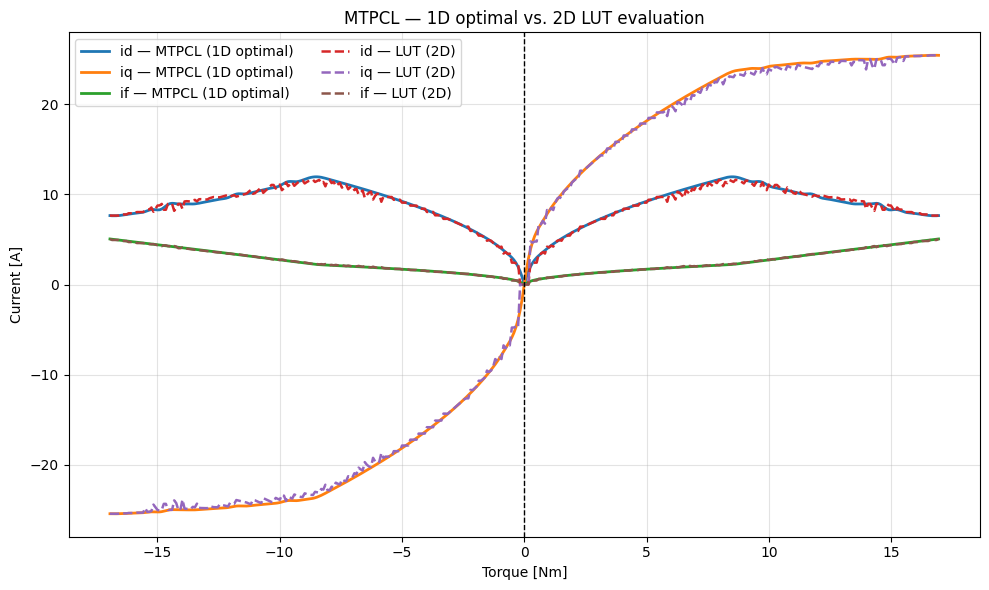

In [9]:
# %% MTPCL — 1D optimal vs. 2D LUT evaluation (no filtering)

import numpy as np
import matplotlib.pyplot as plt

ops = c._controller._operation_point_selection  # LUT holder

# torque axis (use controller's range)
tmax = float(getattr(ops, "t_max", 0.0)) or float(env.reference_generator.limits['torque'])
T = np.linspace(-tmax, tmax, 401)

id_1d, iq_1d, if_1d = [], [], []
id_2d, iq_2d, if_2d = [], [], []

for Tref in T:
    sgn = 1.0 if Tref >= 0 else -1.0
    Tabs = abs(Tref)

    # --- 1D optimal curves (what MTPCL says should be used) ---
    id1 = float(ops.i_d_opt(Tabs))
    iq1 = sgn * float(ops.i_q_opt(Tabs))   # i_q curve is a magnitude → apply sign
    if1 = float(ops.i_e_opt(Tabs))

    # --- 2D LUT sampling (what the controller actually reads from the tables) ---
    try:
        psi = float(ops.psi_opt(Tabs))                           
        Tcap = float(ops.t_max_psi(psi)) if hasattr(ops, "t_max_psi") else Tabs
        T_use = min(Tabs, Tcap)

        if hasattr(ops, "_get_t_idx"):
            ti = int(ops._get_t_idx(T_use))
            pi = int(ops._get_psi_idx(psi))
        else:
           
            ti = int(np.clip(np.abs(ops.t_grid[:, 0] - T_use).argmin(), 0, ops.t_grid.shape[0]-1))
            pi = int(np.clip(np.abs(ops.psi_grid[0, :] - psi).argmin(), 0, ops.psi_grid.shape[1]-1))

        id2 = float(ops.i_d_inter[ti, pi])
        iq2 = sgn * float(ops.i_q_inter[ti, pi])
        if2 = float(ops.i_e_inter[ti, pi])
    except Exception:
        id2, iq2, if2 = np.nan, np.nan, np.nan

    id_1d.append(id1); iq_1d.append(iq1); if_1d.append(if1)
    id_2d.append(id2); iq_2d.append(iq2); if_2d.append(if2)

# to arrays
id_1d = np.array(id_1d); iq_1d = np.array(iq_1d); if_1d = np.array(if_1d)
id_2d = np.array(id_2d); iq_2d = np.array(iq_2d); if_2d = np.array(if_2d)

# --- plot ---
plt.figure(figsize=(10, 6))

plt.plot(T, id_1d, label="id — MTPCL (1D optimal)", lw=2.0)
plt.plot(T, iq_1d, label="iq — MTPCL (1D optimal)", lw=2.0)
plt.plot(T, if_1d, label="if — MTPCL (1D optimal)", lw=2.0)

plt.plot(T, id_2d, "--", label="id — LUT (2D)", lw=1.8)
plt.plot(T, iq_2d, "--", label="iq — LUT (2D)", lw=1.8)
plt.plot(T, if_2d, "--", label="if — LUT (2D)", lw=1.8)

plt.axvline(0, color="k", ls="--", lw=1)
plt.xlabel("Torque [Nm]")
plt.ylabel("Current [A]")
plt.title("MTPCL — 1D optimal vs. 2D LUT evaluation")
plt.grid(True, alpha=0.35)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()




In [10]:
id_MTPCL = np.zeros(len(losses_Tmin))
iq_MTPCL= np.zeros(len(losses_Tmin))
if_MTPCL = np.zeros(len(losses_Tmin))
CuLoss_160 = np.zeros(len(losses_Tmin))
t_MTPCL = np.zeros(len(losses_Tmin))
for i in range(len(losses_Tmin)):
    t_MTPCL[i] = losses_Tmin[i][1]
    if (losses_Tmin[i][2] == None):
        id_MTPCL[i] = id_MTPCL[i-1] 
        iq_MTPCL[i] = iq_MTPCL[i-1]
        if_MTPCL[i] = if_MTPCL[i-1]
        CuLoss_160[i] = CuLoss_160[i-1]
    else:
        id_MTPCL[i] = abs(losses_Tmin[i][2])
        iq_MTPCL[i] = losses_Tmin[i][3]
        if_MTPCL[i] = abs(losses_Tmin[i][4])
        CuLoss_160[i] = losses_Tmin[i][-1]
    
for j in range(len(losses_Tmin)):
    if (t_MTPCL[j] <= 0):
        iq_MTPCL[j] = -iq_MTPCL[j]
    else:
        iq_MTPCL[j] = iq_MTPCL[j]

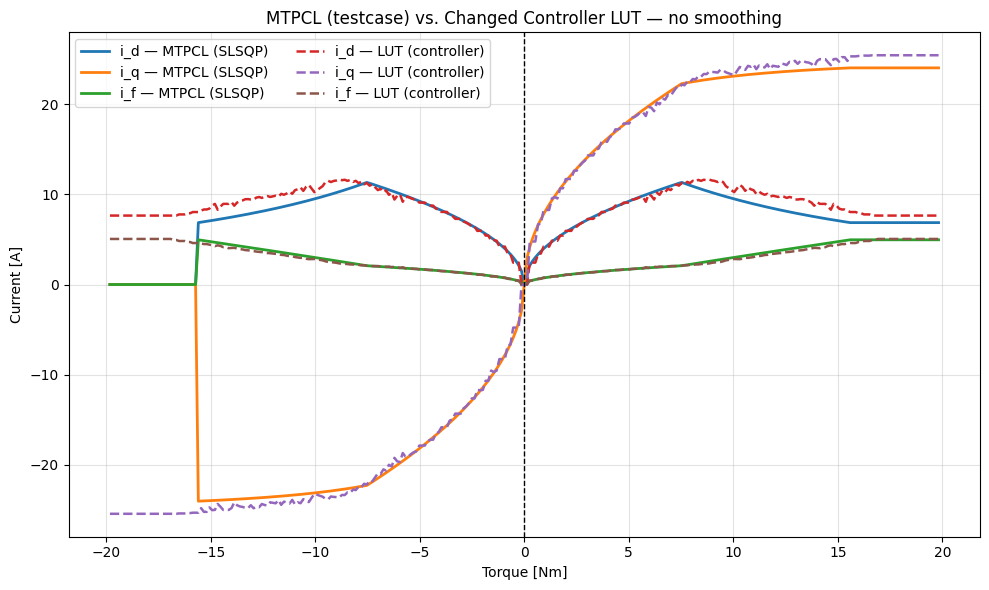

RMSE id  (MTPCL vs LUT): 2.679585580062902
RMSE iq  (MTPCL vs LUT): 8.322803683408381
RMSE if  (MTPCL vs LUT): 1.6348118163918108


In [11]:
# --- Overlay: MTPCL currents (from SLSQP) vs. controller LUT currents (from changed _calculate_luts) ---

import numpy as np
import matplotlib.pyplot as plt

# 1) Grab OPS (Operation Point Selection) from the torque controller
ops = c._controller._operation_point_selection

# 2) Helper to read LUT at a torque T (Nm) using psi = psi_opt(|T|)
def _lut_eval_at_T(T):
    T = float(T)
    sgn = np.sign(T) if T != 0 else 1.0
    T_abs = abs(T)

    
    T_abs = min(T_abs, float(ops.t_max))

    
    psi_opt = float(ops.psi_opt(T_abs))

    
    t_max_at_psi = float(ops.t_max_psi(psi_opt))
    T_use = min(T_abs, t_max_at_psi)

    
    ti    = ops._get_t_idx(T_use)
    psi_i = ops._get_psi_idx(psi_opt)

    # read LUT surfaces (i_q_inter stores magnitude; apply sign from T)
    i_d = float(ops.i_d_inter[ti, psi_i])
    i_q = sgn * float(ops.i_q_inter[ti, psi_i])
    i_f = float(ops.i_e_inter[ti, psi_i])

    if not np.isfinite(i_d): i_d = 0.0
    if not np.isfinite(i_q): i_q = 0.0
    if not np.isfinite(i_f): i_f = 0.0
    return i_d, i_q, i_f

#  Evaluate LUT along the SAME torque points as the MTPCL solution
#    (t_MTPCL is in Nm from your previous cells)
id_LUT = np.zeros_like(t_MTPCL, dtype=float)
iq_LUT = np.zeros_like(t_MTPCL, dtype=float)
if_LUT = np.zeros_like(t_MTPCL, dtype=float)

for k, T in enumerate(t_MTPCL):
    di, qi, fi = _lut_eval_at_T(T)
    id_LUT[k] = di
    iq_LUT[k] = qi
    if_LUT[k] = fi

#  Plot MTPCL (solid) vs LUT (dashed)
plt.figure(figsize=(10,6))

plt.plot(t_MTPCL, id_MTPCL,  label="i_d — MTPCL (SLSQP)", lw=2.0)
plt.plot(t_MTPCL, iq_MTPCL,  label="i_q — MTPCL (SLSQP)", lw=2.0)
plt.plot(t_MTPCL, if_MTPCL,  label="i_f — MTPCL (SLSQP)", lw=2.0)

plt.plot(t_MTPCL, id_LUT, "--", label="i_d — LUT (controller)", lw=1.8)
plt.plot(t_MTPCL, iq_LUT, "--", label="i_q — LUT (controller)", lw=1.8)
plt.plot(t_MTPCL, if_LUT, "--", label="i_f — LUT (controller)", lw=1.8)

plt.axvline(0, color="k", ls="--", lw=1)
plt.xlabel("Torque [Nm]")
plt.ylabel("Current [A]")
plt.title("MTPCL (testcase) vs. Changed Controller LUT — no smoothing")
plt.grid(True, alpha=0.35)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a - b)**2)))

print("RMSE id  (MTPCL vs LUT):", rmse(id_MTPCL, id_LUT))
print("RMSE iq  (MTPCL vs LUT):", rmse(iq_MTPCL, iq_LUT))
print("RMSE if  (MTPCL vs LUT):", rmse(if_MTPCL, if_LUT))


In [ ]:
psi = float(ops.psi_opt(Tabs))
T_use = min(Tabs, float(ops.t_max_psi(psi)))
ti = int(ops._get_t_idx(T_use))
pi = int(ops._get_psi_idx(psi))

i_d_cell = float(ops.i_d_inter[ti, pi])
i_q_cell = sgn * float(ops.i_q_inter[ti, pi])
i_f_cell = float(ops.i_e_inter[ti, pi])
print((ti, pi), (i_d_cell, i_q_cell, i_f_cell))
